In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem


In [2]:
import os
os.chdir("/projects/bgdb/asachan/methods/waterOT")  # adjust path if needed
from utils import *

ModuleNotFoundError: No module named 'src'

In [ ]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

figure_params = {
    'dpi': 300, 
    'bbox_inches': 'tight', 
    'format': 'svg', 
    'transparent': True
}

plt.rcParams.update({
    "text.usetex": False,
    "svg.fonttype": 'none'
})

#### Load and combine scRNA and scATAC-seq data (multiome - so cell barcodes are shared)

In [8]:
rna_path = '/work/hdd/bgdb/asachan/datasets_proj/Bcell_in_vitro_human/objects/stream_input_filtered_cells_v7.h5ad'
atac_path = '/work/hdd/bgdb/asachan/datasets_proj/Bcell_in_vitro_human/objects/adata_aggregated_peak.leiden.h5ad'

In [ ]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 28494 × 3018
    obs: 'cell_type_major', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'topic_22', 'topic_23', 'topic_24', 'topic_25', 'topic_26', 'topic_27', 'topic_28', 'topic_29', 'topic_30', 'topic_31', 'leiden', 'sub_cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'DM_EigenValues', 'cell_type_major_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sub_cell_type_colors', 'topic_dendogram', 'umap'
    obsm: 'DM_EigenVectors', 'X_joint_umap_features',

In [10]:
rna_adata.X = rna_adata.layers["counts"]
display(rna_adata.X.max())

np.float32(949.0)

In [ ]:
sc.pl.umap(rna_adata, color=['cell_type_major', 'sub_cell_type'])

In [ ]:
rna_adata.obs['cell_type_major']

In [11]:
atac_adata = sc.read_h5ad(atac_path)
atac_adata

AnnData object with n_obs × n_vars = 32418 × 191255
    obs: 'cell_type_major', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'topic_5', 'topic_6', 'topic_7', 'topic_8', 'topic_9', 'topic_10', 'topic_11', 'topic_12', 'topic_13', 'topic_14', 'topic_15', 'topic_16', 'topic_17', 'topic_18', 'topic_19', 'topic_20', 'topic_21', 'cell_index', 'leiden_joint'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'topic_dendogram'
    obsm: 'X_joint_umap_features', 'X_topic_compositions', 'X_umap_features'
    varm: 'topic_feature_activations', 'topic_feature_compositions'
    layers: 'counts'

In [12]:
atac_adata.X = atac_adata.layers["counts"]
display(atac_adata.X.max())

np.float32(190.0)

In [ ]:
atac_adata.var

In [ ]:
# check shared cells
shared = rna_adata.obs_names.intersection(atac_adata.obs_names)
print("shared cells:", len(shared))

In [ ]:
atac_adata = atac_adata[shared].copy()

# Import mudata

In [ ]:
import muon as mu

mdata = mu.read_h5mu('/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/rna_atac_multivi.h5mu')
mdata

In [ ]:
X = mdata.obsm["X_MultiVI"]
X.shape

In [ ]:
common = rna_adata.obs_names.intersection(mdata.obs_names)
assert len(common) == rna_adata.n_obs == mdata.n_obs

rna_adata.obsm["X_MultiVI"] = mdata[rna_adata.obs_names].obsm["X_MultiVI"]


### Cleanup cell states by day

In [ ]:
# 'ActB-1',
#  'ActB-2',
#  'ActB-3',
#  'ActB-4',
#  'GC-1',
#  'GC-2',
#  'PB-2',
#  'earlyActB',
#  'earlyPB'
adata_subset = rna_adata[rna_adata.obs['sub_cell_type'] == "PB-2"]

### keeping only the cell types that are present in the day-slot with population >100

In [ ]:
# keeping only the cell types that are present in the day-slot with population >100
adata_subset.obs['cell_type_major'].value_counts()

In [ ]:
keep_by_day = {
    "day0_2": ["earlyActB", "ActB-1", "ActB-2"],
    "day3_4": ["ActB-2", "ActB-3", "ActB-4", "earlyPB"],
    "day5_6": ["GC-1", "GC-2", "PB-2"],
}

day_key = "cell_type_major"
ct_key  = "sub_cell_type"

mask = rna_adata.obs.apply(lambda r: r[ct_key] in keep_by_day.get(r[day_key], []), axis=1)

adata_asym = rna_adata[mask].copy()

# cleanup
adata_asym.obs[ct_key] = adata_asym.obs[ct_key].astype("category").cat.remove_unused_categories()
adata_asym.obs[day_key] = adata_asym.obs[day_key].astype("category").cat.remove_unused_categories()

In [ ]:
adata_asym

In [ ]:
# make temporal info numeric
def adapt_time(x):
    if x["cell_type_major"] == "day0_2":
        return 1.5
    if x["cell_type_major"] == "day3_4":
        return 3.5
    if x["cell_type_major"] == "day5_6":
        return 5.5
    raise ValueError

adata_asym.obs["cell_type_major"] = adata_asym.obs.apply(adapt_time, axis=1).astype("category")

# OT solver

In [ ]:
# instantiate temporal OT problem
tp0 = TemporalProblem(adata_asym)
tp0 = tp0.prepare(time_key="cell_type_major", joint_attr="X_MultiVI")

In [ ]:
import networkx as nx

dfs = {}
batch_column = "cell_type_major"
unique_batches = [1.5, 3.5, 5.5]

# pair wise WOT
for i in range(len(unique_batches) - 1):
    batch1 = unique_batches[i]
    batch2 = unique_batches[i + 1]

    indices = np.where(
        (adata_asym.obs[batch_column] == batch1) | (adata_asym.obs[batch_column] == batch2)
    )[0]
    adata_subset = adata_asym[indices]

    sc.pp.neighbors(adata_subset, use_rep="X_MultiVI", n_neighbors=30)
    G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
    assert nx.is_connected(G)

    # store the kNN graph as a dense pandas df and save it in a dict
    dfs[(batch1, batch2)] = pd.DataFrame(
        index=adata_subset.obs_names,
        columns=adata_subset.obs_names,
        data=adata_subset.obsp["connectivities"].todense().astype("float"),
    )

In [ ]:
for (t1, t2) in [(1.5, 3.5), (3.5, 5.5)]:
    prob = tp0[t1, t2]

    expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)  # Index
    Gdf = dfs[(t1, t2)].loc[expected, expected].astype(float)

    prob.set_graph_xy(Gdf, t=100.0)


In [ ]:
# epsilon: entropic regularization strength
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7)

In [ ]:
import cloudpickle
tmp_dir = "/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/tmp"
with open(f'{tmp_dir}/tp0_asym.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

In [ ]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix
T_35_55 = tp0[3.5, 5.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)
T_35_55_np = np.asarray(T_35_55)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)
T_35_55_csr = sp.csr_matrix(T_35_55_np)

sp.save_npz(os.path.join(tmp_dir, "T_1.5_3.5.npz"), T_15_35_csr)
sp.save_npz(os.path.join(tmp_dir, "T_3.5_5.5.npz"), T_35_55_csr)

# Vizualize

In [5]:
# load tp0 object
import pickle
with open('/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/tmp/tp0_asym.pkl', 'rb') as f:
    tp0 = pickle.load(f)


In [6]:
order_celltypes = ['earlyActB','ActB-1',
 'ActB-2',
 'ActB-3',
 'ActB-4',
 'earlyPB',
 'PB-2',
 'GC-1',
 'GC-2']

order_celltypes

['earlyActB',
 'ActB-1',
 'ActB-2',
 'ActB-3',
 'ActB-4',
 'earlyPB',
 'PB-2',
 'GC-1',
 'GC-2']

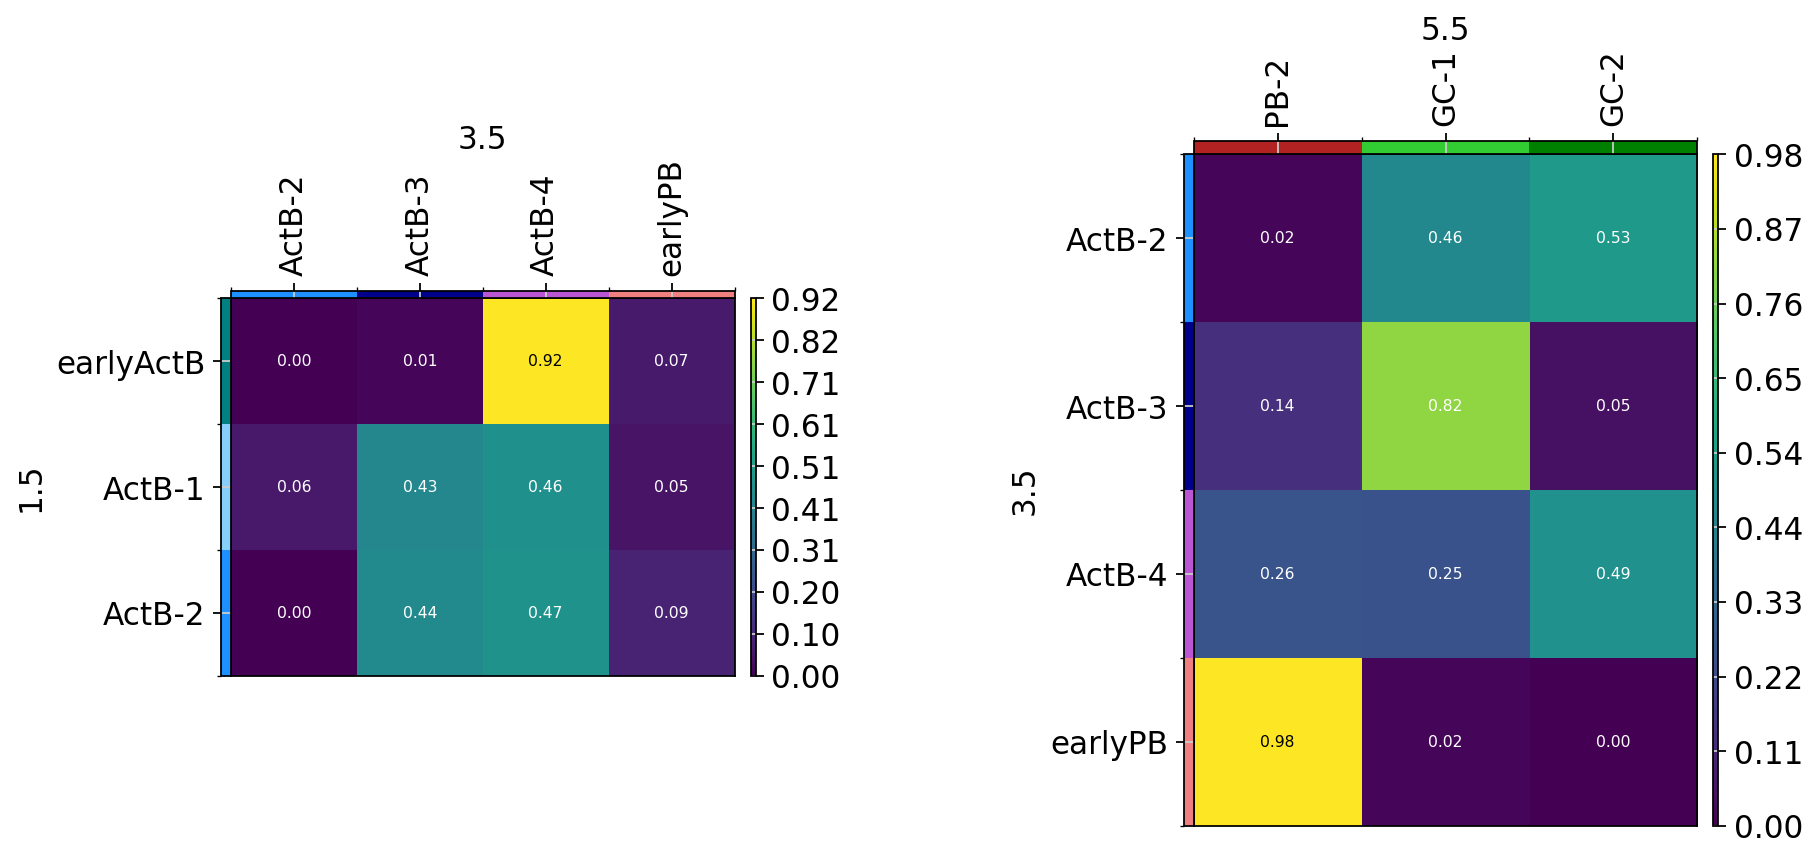

In [7]:
ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=True, # descendant plots
    key_added="transitions_1.5_3.5",
)
ct_desc = tp0.cell_transition(
    3.5,
    5.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=True,
    key_added="transitions_3.5_5.5",
)

# Create a 1x2 grid of subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="transitions_1.5_3.5",
)

axes[1] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="transitions_3.5_5.5",
)


fig.subplots_adjust(wspace=0.8)
# save fig
#fig.savefig("/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/descendant_plots.svg", format="svg", bbox_inches="tight")

In [ ]:
ct_ansc = tp0.cell_transition(
    1.5,
    3.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=False, # ancestor plots
    key_added="transitions_1.5_3.5_large",
)
ct_ansc = tp0.cell_transition(
    3.5,
    5.5,
    {"sub_cell_type": order_celltypes},
    {"sub_cell_type": order_celltypes},
    forward=False,
    key_added="transitions_3.5_5.5_large",
)

# Create a 1x2 grid of subplots
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))

axes[0] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[0],
    key="transitions_1.5_3.5_large",
)

axes[1] = mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(5, 5),
    return_fig=True,
    ax=axes[1],
    key="transitions_3.5_5.5_large",
)


fig.subplots_adjust(wspace=0.8)
# save fig
#fig.savefig("/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/ancestor_plots.svg", format="svg", bbox_inches="tight")


In [ ]:
tp0.pull(source=1.5, target=3.5, data="sub_cell_type", subset="ActB-4")
fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

mpl.pull(
    tp0,
    time_points=[3.5],
    basis="X_umap",
    ax=axes[0],
    title=["ActB-4 cells at time 3.5"],
)

mpl.pull(
    tp0,
    time_points=[1.5],
    basis="X_umap",
    ax=axes[1],
    title=["ActB-4 cells ancestors"],
)

fig.subplots_adjust(wspace=0.3)

In [ ]:
tp0.push(source=3.5, target=5.5, data="sub_cell_type", subset="ActB-4")
fig, axes = plt.subplots(ncols=2, figsize=(16, 4))

mpl.push(
    tp0,
    time_points=[3.5],
    basis="X_umap",
    ax=axes[0],
    title=["ActB-4 cells at time 1.5"],
)

mpl.push(
    tp0,
    time_points=[5.5],
    basis="X_umap",
    ax=axes[1],
    title=["ActB-4 cells descendants"],
)

fig.subplots_adjust(wspace=0.3)

In [ ]:
# tp0.sankey(
#     source=3.5,
#     target=5.5,
#     source_groups={"sub_cell_type": order_celltypes},
#     target_groups={"sub_cell_type": order_celltypes},
#     threshold=0.05,
#     order_annotations=order_celltypes[::-1],
#     normalize=True,
# )
# mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True, save="/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/sankey_3.5_5.5.pdf")

In [ ]:
# tp0.sankey(
#     source=1.5,
#     target=3.5,
#     source_groups={"sub_cell_type": order_celltypes},
#     target_groups={"sub_cell_type": order_celltypes},
#     threshold=0.05,
#     order_annotations=order_celltypes[::-1],
#     normalize=True,
# )
# mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True, save="/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/sankey_1.5_3.5.pdf")

## Driver TFs of pre-disposed population transitions 
#### using pull-back probability from the coupling matrix

In [8]:
X_orig = tp0.adata.X.copy()

# 1) Put raw counts into X
tp0.adata.X = tp0.adata.layers["counts"].copy()

# 2) Remove stale flag so scanpy won't warn
tp0.adata.uns.pop("log1p", None)

# 3) Normalize + log1p (now valid because X is counts)
sc.pp.normalize_total(tp0.adata, target_sum=1e4)
sc.pp.log1p(tp0.adata)


[pull] key='ActB-4_GC-2_pull' | combined weight sum = 6915.9983

[result] 38 significant drivers (qval<0.05, |corr|>0.1)


,ActB-4_GC-2_corr,ActB-4_GC-2_pval,ActB-4_GC-2_qval,ActB-4_GC-2_ci_low,ActB-4_GC-2_ci_high,significant
IKZF2,0.490600,0.000000,0.000000,0.474996,0.505894,True
ZBTB20,0.258300,0.000000,0.000000,0.239213,0.277187,True
STAT4,0.243274,0.000000,0.000000,0.224039,0.262320,True
BCL6,0.210869,0.000000,0.000000,0.191346,0.230225,True
NR3C2,0.180154,0.000000,0.000000,0.160398,0.199766,True
PAX5,0.147396,0.000000,0.000000,0.127434,0.167239,True
RUNX1,0.145366,0.000000,0.000000,0.125393,0.165222,True
MXI1,0.127413,0.000000,0.000000,0.107348,0.147375,True
NR4A3,0.126154,0.000000,0.000000,0.106082,0.146123,True
ZNF831,0.113818,0.000000,0.000000,0.093691,0.133852,True


,ActB-4_GC-2_corr,ActB-4_GC-2_pval,ActB-4_GC-2_qval,ActB-4_GC-2_ci_low,ActB-4_GC-2_ci_high,significant
IRF4,-0.298131,0.000000,0.000000,-0.316555,-0.279482,True
PRDM1,-0.291369,0.000000,0.000000,-0.309876,-0.272641,True
BATF,-0.286615,0.000000,0.000000,-0.305180,-0.267833,True
AHR,-0.280017,0.000000,0.000000,-0.298659,-0.261160,True
NFKB1,-0.262054,0.000000,0.000000,-0.280901,-0.243005,True
RUNX2,-0.237791,0.000000,0.000000,-0.256893,-0.218504,True
TCF12,-0.231989,0.000000,0.000000,-0.251148,-0.212649,True
ESR1,-0.231466,0.000000,0.000000,-0.250630,-0.212121,True
XBP1,-0.214571,0.000000,0.000000,-0.233894,-0.195079,True
RELB,-0.189817,0.000000,0.000000,-0.209353,-0.170130,True


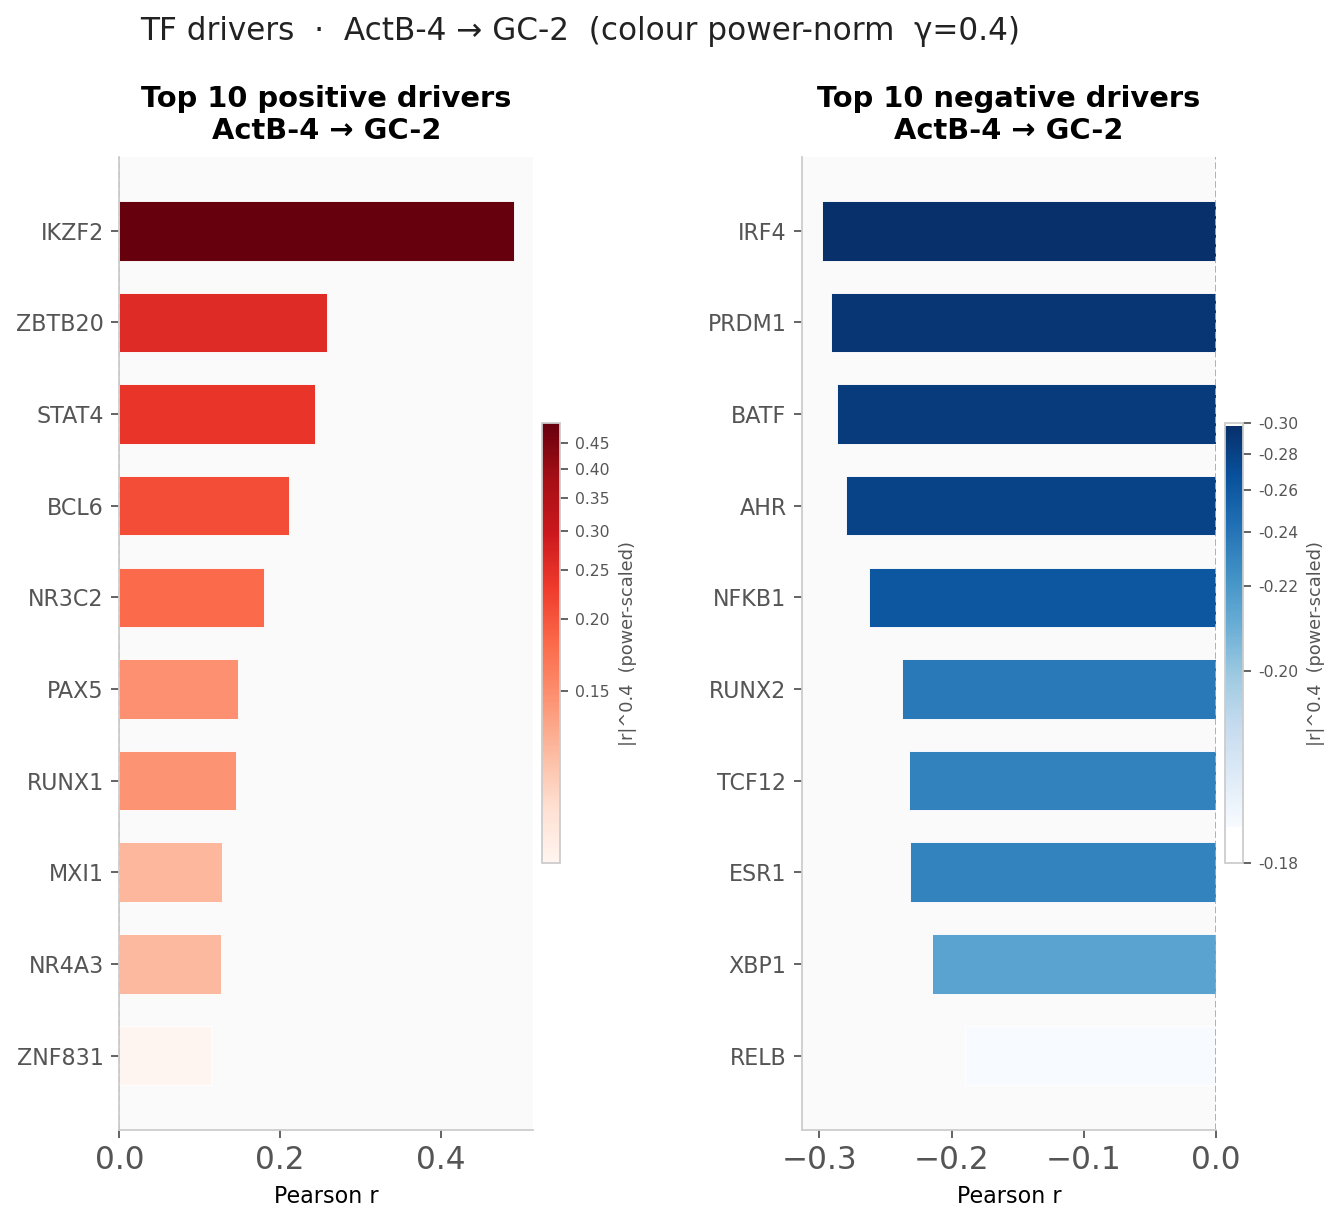

In [9]:
drivers, top_pos, top_neg = drivers_tf_for_subset(
    tp0, subset=("ActB-4", "GC-2")
)

fig = plot_drivers(drivers, subset=("ActB-4", "GC-2"))
# save fig
#fig.savefig("/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/tf_drivers_actb4_gc1.svg", format="svg", bbox_inches="tight")


## derive the push probability

In [14]:
desc_phenotype, top_pos, top_neg = desc_phenotype_for_subset(
    tp0, subset="ActB-4",
    t_points=(3.5, 5.5),
    subset_annotation={"sub_cell_type": ['GC-2']},  # cell type filter on descendants
    features="human"
)

[push] key='ActB-4_push' | combined weight sum = 1.0000

[result] 8 significant drivers (qval<0.05, |corr|>0.1)


,ActB-4_corr,ActB-4_pval,ActB-4_qval,ActB-4_ci_low,ActB-4_ci_high,significant
PPARG,0.133208,0.000000,0.000000,0.094429,0.171584,True
ZNF704,0.128140,0.000000,0.000000,0.089316,0.166575,True
HNF1B,0.116381,0.000000,0.000000,0.077462,0.154946,True
ZEB2,0.106592,0.000000,0.000003,0.067602,0.145258,True
NR4A3,0.102093,0.000000,0.000009,0.063072,0.140802,True
TCF7L2,0.098466,0.000001,0.000016,0.059422,0.137209,False
THRB,0.082884,0.000034,0.000481,0.043753,0.121761,False
NFATC1,0.081716,0.000044,0.000542,0.042579,0.120602,False
IKZF2,0.080234,0.000061,0.000663,0.041090,0.119132,False
PLAGL1,0.076411,0.000134,0.001370,0.037249,0.115338,False


,ActB-4_corr,ActB-4_pval,ActB-4_qval,ActB-4_ci_low,ActB-4_ci_high,significant
BCL11A,-0.134024,0.000000,0.000000,-0.172390,-0.095252,True
ESR1,-0.110769,0.000000,0.000001,-0.149392,-0.071808,True
POU2AF1,-0.100789,0.000000,0.000011,-0.139510,-0.061760,True
BATF,-0.099892,0.000001,0.000013,-0.138622,-0.060858,False
IKZF1,-0.097576,0.000001,0.000019,-0.136327,-0.058526,False
ZBTB7A,-0.086132,0.000017,0.000272,-0.124982,-0.047017,False
AHR,-0.085703,0.000018,0.000276,-0.124558,-0.046587,False
PBX3,-0.081984,0.000042,0.000542,-0.120868,-0.042848,False
KDM7A,-0.081209,0.000049,0.000570,-0.120099,-0.042069,False
XBP1,-0.076232,0.000139,0.001370,-0.115161,-0.037070,False


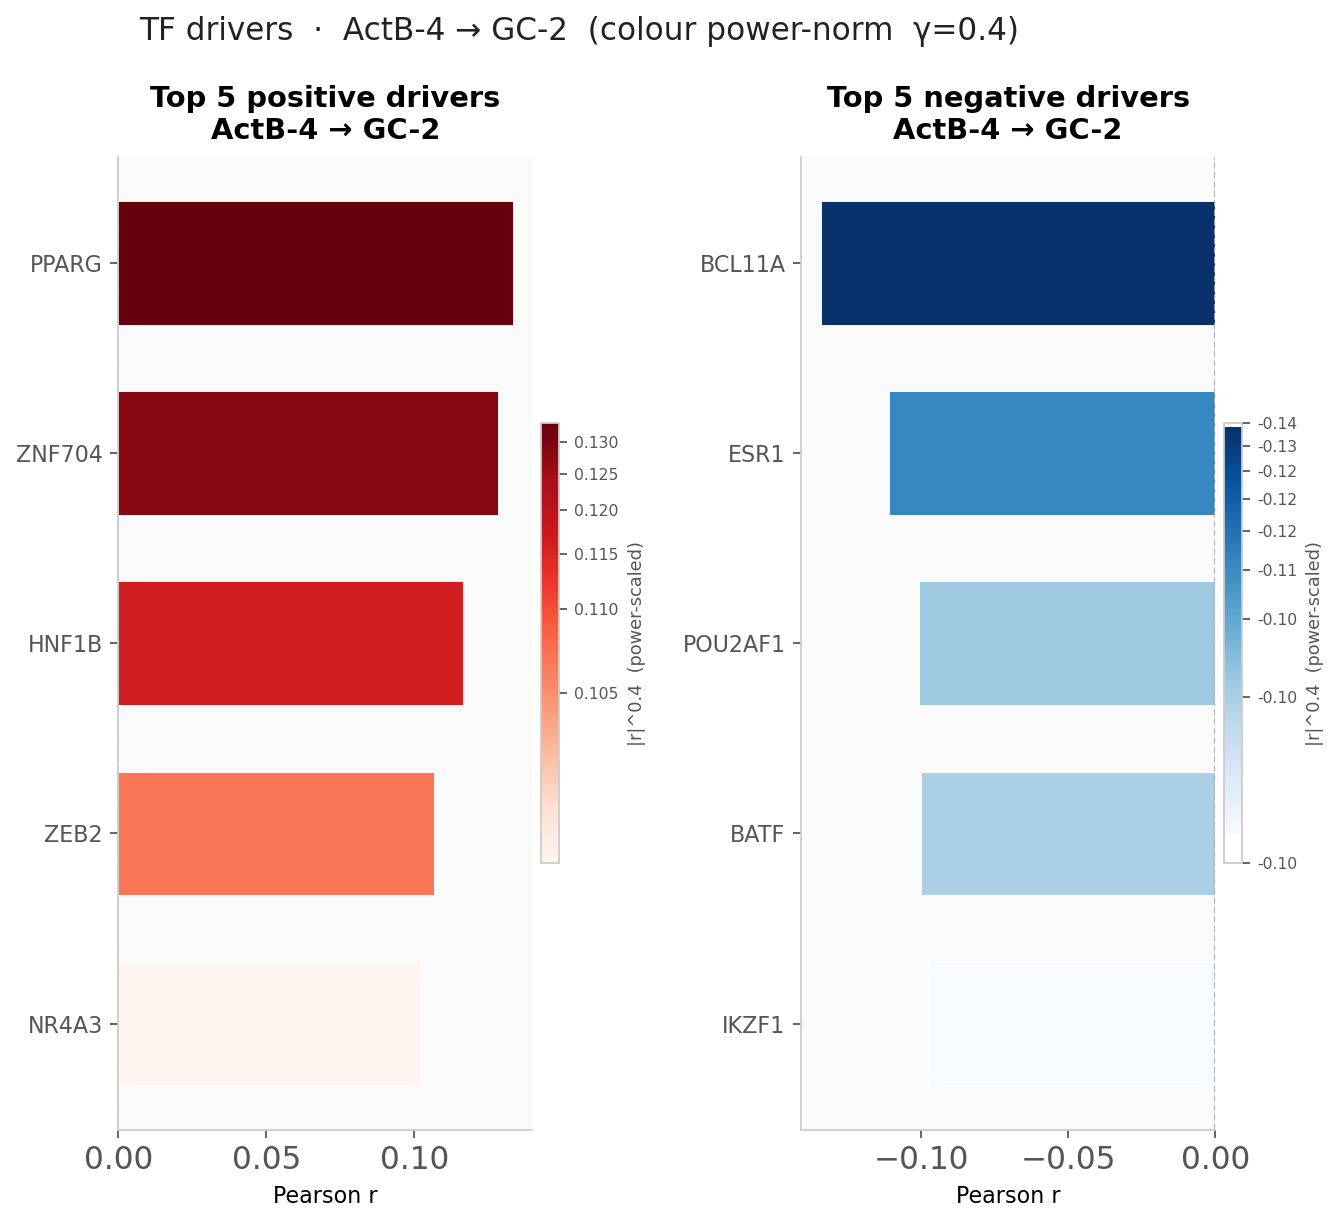

In [15]:
fig = plot_drivers(drivers=desc_phenotype, subset=("ActB-4", "GC-2"), n_top=5, obs_key_prefix="ActB-4")
fig.show()

#save svg
fig.savefig("/projects/bgdb/asachan/datasets/Bcell_in_vitro_human/figs/desc_tfs_actb4_gc2.svg", format="svg", bbox_inches="tight")